In [1]:
# Install packages
!pip install transformers pillow torch matplotlib -q

import torch
import matplotlib.pyplot as plt

from PIL import Image
from transformers import AutoProcessor, AutoModel
from google.colab import files

In [2]:
print("STEP 1 — Loading model")

model_name = "google/siglip-base-patch16-224"

model = AutoModel.from_pretrained(model_name)
processor = AutoProcessor.from_pretrained(model_name)

print("Model loaded successfully")
print("Model name:", model_name)


STEP 1 — Loading model


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/711 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.40M [00:00<?, ?B/s]

Model loaded successfully
Model name: google/siglip-base-patch16-224



# STEP 2 — UPLOAD IMAGE



STEP 2 — Upload image


Saving images.jpg to images.jpg
Image loaded
Image size: (194, 260)


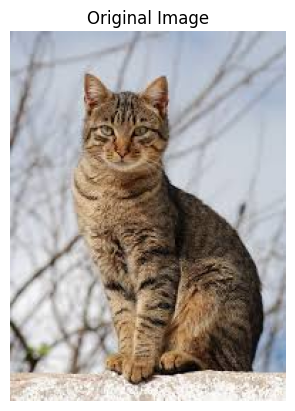

In [3]:


print("\nSTEP 2 — Upload image")

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

image = Image.open(image_path).convert("RGB")

print("Image loaded")
print("Image size:", image.size)

# Show image
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()



# STEP 3 — SPLIT IMAGE INTO PATCHES

In [4]:


print("\nSTEP 3 — Splitting image into patches")

def split_into_patches_with_coords(img, patch_size=64, stride=64):

    patches = []
    coords = []

    w, h = img.size

    print("Width:", w)
    print("Height:", h)

    for top in range(0, h - patch_size + 1, stride):

        for left in range(0, w - patch_size + 1, stride):

            patch = img.crop(
                (left, top, left + patch_size, top + patch_size)
            )

            patches.append(patch)

            coords.append(
                (left, top, left + patch_size, top + patch_size)
            )

            print(
                f"Created patch at coordinates:"
                f" ({left}, {top}, {left + patch_size}, {top + patch_size})"
            )

    return patches, coords

patches, coords = split_into_patches_with_coords(
    image,
    patch_size=64,
    stride=64
)

print("\nTotal patches:", len(patches))


STEP 3 — Splitting image into patches
Width: 194
Height: 260
Created patch at coordinates: (0, 0, 64, 64)
Created patch at coordinates: (64, 0, 128, 64)
Created patch at coordinates: (128, 0, 192, 64)
Created patch at coordinates: (0, 64, 64, 128)
Created patch at coordinates: (64, 64, 128, 128)
Created patch at coordinates: (128, 64, 192, 128)
Created patch at coordinates: (0, 128, 64, 192)
Created patch at coordinates: (64, 128, 128, 192)
Created patch at coordinates: (128, 128, 192, 192)
Created patch at coordinates: (0, 192, 64, 256)
Created patch at coordinates: (64, 192, 128, 256)
Created patch at coordinates: (128, 192, 192, 256)

Total patches: 12


# STEP 4 — SHOW SOME PATCHES



STEP 4 — Displaying patches


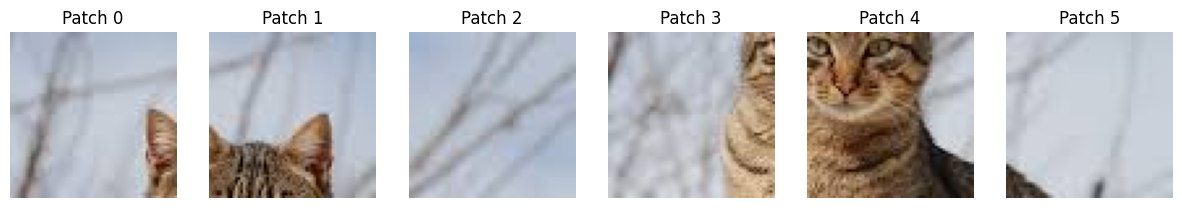

In [5]:

print("\nSTEP 4 — Displaying patches")

num_to_show = min(6, len(patches))

fig, axes = plt.subplots(1, num_to_show, figsize=(15, 5))

for i in range(num_to_show):

    axes[i].imshow(patches[i])

    axes[i].set_title(f"Patch {i}")

    axes[i].axis("off")

plt.show()



# STEP 5 — TEXT PROMPTS


In [6]:
print("\nSTEP 5 — Define text prompts")

texts = ["a cat", "a dog", "a car"]

print("Texts:", texts)


STEP 5 — Define text prompts
Texts: ['a cat', 'a dog', 'a car']




# STEP 6 — PROCESS INPUTS


In [7]:


print("\nSTEP 6 — Processor step")

inputs = processor(
    text=texts,
    images=patches,
    return_tensors="pt",
    padding=True
)

print("Processor output keys:")
print(inputs.keys())

print("\nInput tensor shapes:")

for key, value in inputs.items():

    print(key, value.shape)



STEP 6 — Processor step
Processor output keys:
KeysView({'pixel_values': tensor([[[[ 0.1922,  0.2000,  0.2078,  ...,  0.3647,  0.3647,  0.3647],
          [ 0.1922,  0.2000,  0.2078,  ...,  0.3647,  0.3647,  0.3647],
          [ 0.1922,  0.2000,  0.2078,  ...,  0.3647,  0.3647,  0.3647],
          ...,
          [ 0.4588,  0.4510,  0.4353,  ...,  0.4275,  0.4667,  0.4902],
          [ 0.4588,  0.4510,  0.4353,  ...,  0.5059,  0.5529,  0.5765],
          [ 0.4588,  0.4510,  0.4353,  ...,  0.5294,  0.5843,  0.6157]],

         [[ 0.2549,  0.2627,  0.2706,  ...,  0.4667,  0.4667,  0.4667],
          [ 0.2549,  0.2627,  0.2706,  ...,  0.4667,  0.4667,  0.4667],
          [ 0.2549,  0.2627,  0.2706,  ...,  0.4667,  0.4667,  0.4667],
          ...,
          [ 0.4588,  0.4431,  0.4275,  ...,  0.1608,  0.2000,  0.2157],
          [ 0.4588,  0.4431,  0.4275,  ...,  0.2392,  0.2863,  0.3098],
          [ 0.4588,  0.4431,  0.4275,  ...,  0.2627,  0.3176,  0.3490]],

         [[ 0.4039,  0.4118,


# STEP 7 — MODEL FORWARD PASS


In [8]:


print("\nSTEP 7 — Running model")

with torch.no_grad():

    outputs = model(**inputs)

print("Model finished")

print("\nOutput keys:")
print(outputs.keys())



STEP 7 — Running model
Model finished

Output keys:
odict_keys(['logits_per_image', 'logits_per_text', 'text_embeds', 'image_embeds', 'text_model_output', 'vision_model_output'])



# STEP 8 — LOGITS


In [9]:


print("\nSTEP 8 — Extract logits")

logits = outputs.logits_per_image

print("Logits shape:", logits.shape)

print("\nRaw logits:")
print(logits)



STEP 8 — Extract logits
Logits shape: torch.Size([12, 3])

Raw logits:
tensor([[-10.3150, -10.1112, -10.1866],
        [-11.5436, -11.6302, -16.2024],
        [-13.6015, -12.5045, -14.6476],
        [-10.7992, -10.3446, -12.7138],
        [-11.2437, -11.8826, -16.0199],
        [-10.4307,  -9.5058,  -9.7478],
        [ -8.8618,  -8.5161, -10.3652],
        [-10.3663, -11.0157, -13.5720],
        [-11.6452, -12.4475, -16.2358],
        [-13.1015, -11.5219, -14.1870],
        [-10.0721,  -9.5901, -12.3734],
        [-10.9453,  -9.7075, -13.4095]])



# STEP 9 — SOFTMAX


In [10]:


print("\nSTEP 9 — Convert logits to probabilities")

probs = torch.softmax(logits, dim=-1)

print("Probabilities shape:", probs.shape)

print("\nProbabilities:")
print(probs)




STEP 9 — Convert logits to probabilities
Probabilities shape: torch.Size([12, 3])

Probabilities:
tensor([[0.2974, 0.3646, 0.3381],
        [0.5191, 0.4760, 0.0049],
        [0.2301, 0.6891, 0.0808],
        [0.3672, 0.5786, 0.0541],
        [0.6509, 0.3436, 0.0055],
        [0.1818, 0.4584, 0.3598],
        [0.3795, 0.5362, 0.0844],
        [0.6399, 0.3342, 0.0259],
        [0.6857, 0.3074, 0.0070],
        [0.1615, 0.7839, 0.0546],
        [0.3677, 0.5955, 0.0368],
        [0.2206, 0.7606, 0.0188]])


# STEP 10 — FINAL RESULTS



STEP 10 — Final classification per patch

Patch 0
Coordinates: (0, 0, 64, 64)


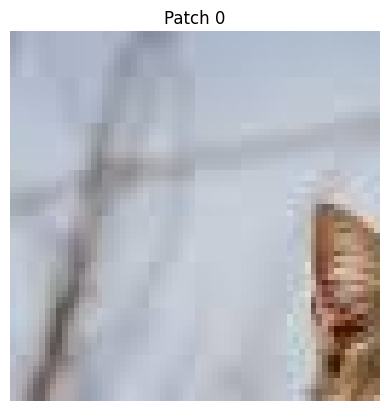

a cat: 0.2974
a dog: 0.3646
a car: 0.3381

Patch 1
Coordinates: (64, 0, 128, 64)


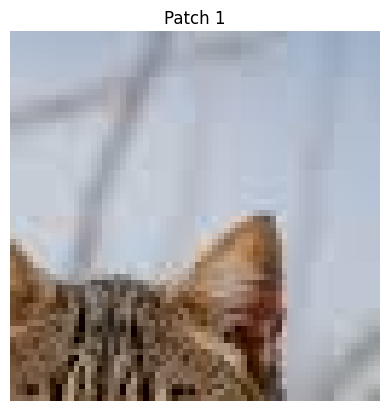

a cat: 0.5191
a dog: 0.4760
a car: 0.0049

Patch 2
Coordinates: (128, 0, 192, 64)


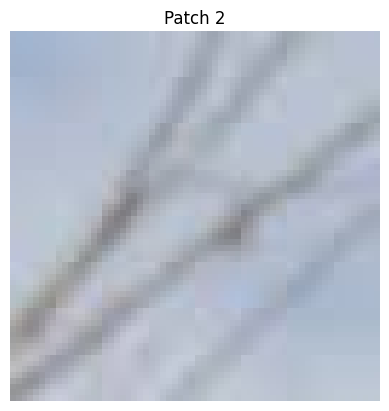

a cat: 0.2301
a dog: 0.6891
a car: 0.0808

Patch 3
Coordinates: (0, 64, 64, 128)


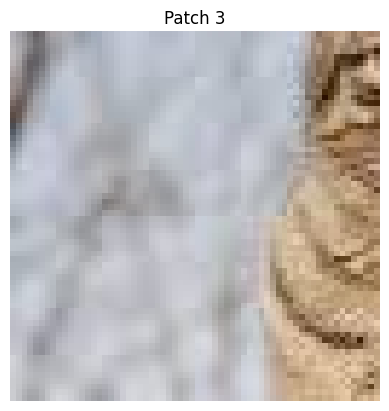

a cat: 0.3672
a dog: 0.5786
a car: 0.0541

Patch 4
Coordinates: (64, 64, 128, 128)


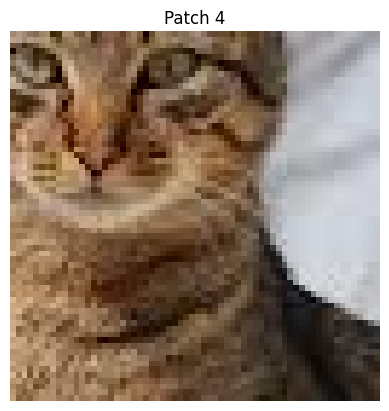

a cat: 0.6509
a dog: 0.3436
a car: 0.0055

Patch 5
Coordinates: (128, 64, 192, 128)


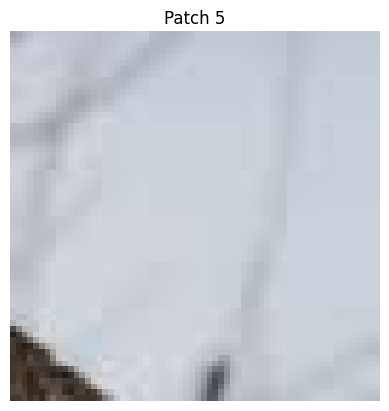

a cat: 0.1818
a dog: 0.4584
a car: 0.3598

Patch 6
Coordinates: (0, 128, 64, 192)


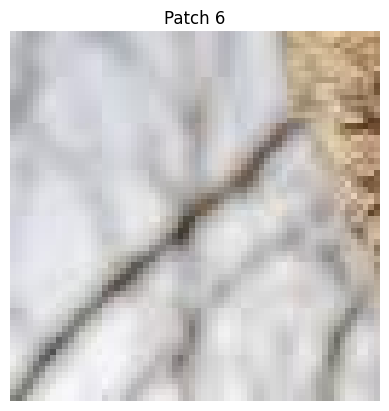

a cat: 0.3795
a dog: 0.5362
a car: 0.0844

Patch 7
Coordinates: (64, 128, 128, 192)


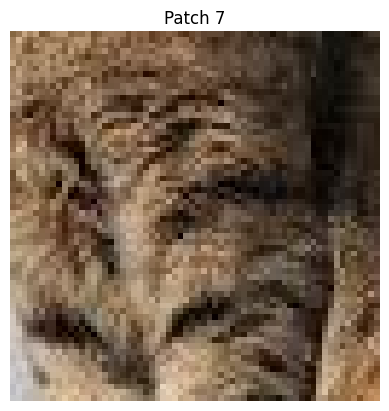

a cat: 0.6399
a dog: 0.3342
a car: 0.0259

Patch 8
Coordinates: (128, 128, 192, 192)


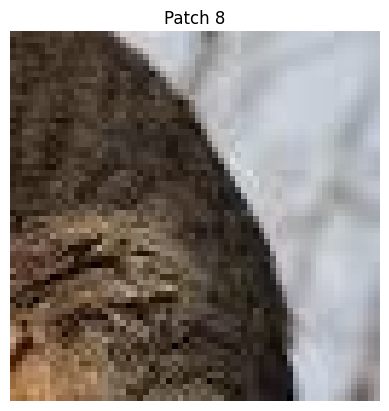

a cat: 0.6857
a dog: 0.3074
a car: 0.0070

Patch 9
Coordinates: (0, 192, 64, 256)


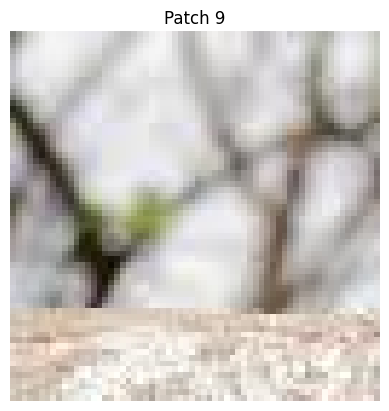

a cat: 0.1615
a dog: 0.7839
a car: 0.0546

Patch 10
Coordinates: (64, 192, 128, 256)


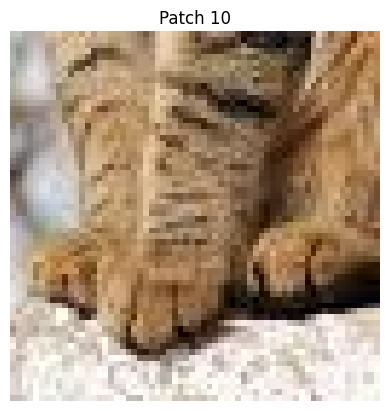

a cat: 0.3677
a dog: 0.5955
a car: 0.0368

Patch 11
Coordinates: (128, 192, 192, 256)


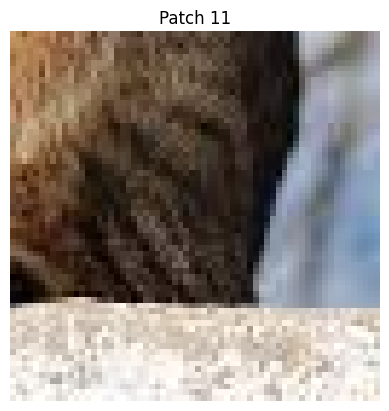

a cat: 0.2206
a dog: 0.7606
a car: 0.0188


In [11]:


print("\nSTEP 10 — Final classification per patch")

for i, patch_probs in enumerate(probs):

    print("\n==============================")
    print(f"Patch {i}")
    print("Coordinates:", coords[i])

    # Show patch
    plt.imshow(patches[i])
    plt.title(f"Patch {i}")
    plt.axis("off")
    plt.show()

    for text, score in zip(texts, patch_probs):

        print(f"{text}: {score.item():.4f}")